## **Alumno:** <span style="color:red">**Juan Manuel Resquin**</span>


In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('E:/CIENCIA DE DATOS E IA/2-SEGUNDO AÑO\SEGUNDO CUATRIMESTRE/2- LABORATORIO DE MINERIA Y DATOS/Proyecto_AndesLink/data/churn_sintetico.csv')
print(df.head())

   tenure_months  monthly_charge  total_charges  support_tickets  \
0              7           58.23         326.50                2   
1             56           56.75        3154.21                0   
2             48           78.84        3864.31                3   
3             32           79.74        2511.40                0   
4             32           55.37        1735.51                3   

   late_payments  avg_monthly_usage_gb contract_type payment_method  \
0              1                 81.83       mensual  transferencia   
1              2                 96.52         anual         debito   
2              2                 93.60       bianual       efectivo   
3              0                 28.95       bianual         debito   
4              0                126.90         anual       efectivo   

  internet_service  has_streaming  has_security_pack  num_products  region  \
0            cable              0                  1             3  centro   
1       

In [41]:
# Conectamos con DagsHub
import dagshub
dagshub.init(repo_owner='JuanManuelResquin84', repo_name='Proyecto_AndesLink', mlflow=True)

import mlflow
with mlflow.start_run():
  mlflow.log_param('parameter name', 'value')
  mlflow.log_metric('metric name', 1)

Initialized MLflow to track repo "JuanManuelResquin84/Proyecto_AndesLink"

Repository JuanManuelResquin84/Proyecto_AndesLink initialized!

🏃 View run delicate-mole-488 at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/08816962e4814887958f821f43d79db8
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0


In [42]:
# Preparamos los datos para el entrenamiento
import pandas as pd
import mlflow
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

#1 Preparación de Datos (Copia y Limpieza)
df_ml = df.copy()

#2 Encoding
# Usamos One-Hot Encoding para las características (X)
# Esto crea columnas de 0 y 1 para categorías como 'plan_internet' o 'genero'
X = pd.get_dummies(df_ml.drop('churn', axis=1), drop_first=True)

#2 Usamos LabelEncoder solo para la variable objetivo (y)
le = LabelEncoder()
y = le.fit_transform(df_ml['churn'])

#3 División del Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [43]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, cohen_kappa_score, classification_report
import mlflow

with mlflow.start_run(run_name="RandomForest_1"):
    
    # Configuramos el modelo con los pesos manuales
    n_est = 100
    max_d = 5
    
    model = RandomForestClassifier(
        n_estimators=n_est, 
        max_depth=max_d, 
        random_state=42
    )
    
    # Entrenamos
    model.fit(X_train, y_train)
    
    # Predecimos
    y_pred = model.predict(X_test)
    
    # Calculo de las metricas
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    
    # LOGS PARA DAGSHUB
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", n_est)
    mlflow.log_param("max_depth", max_d)
    mlflow.log_param("encoding_type", "OneHot")
    mlflow.log_param("class_weight_ratio", "1:1.8")
    
    
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("kappa", kappa)
    
    # Mostramos resultados en consola
    print(f"Random Forest - Accuracy: {accuracy:.4f} | Recall: {recall:.4f}")
    print(f"Kappa: {kappa:.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))

Random Forest - Accuracy: 0.7090 | Recall: 0.2529
Kappa: 0.2329

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.71      0.94      0.81       660
           1       0.70      0.25      0.37       340

    accuracy                           0.71      1000
   macro avg       0.70      0.60      0.59      1000
weighted avg       0.71      0.71      0.66      1000

🏃 View run RandomForest_1 at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/c73aa5b989424483901c95eccc68e395
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0


In [44]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, cohen_kappa_score, classification_report
import mlflow

with mlflow.start_run(run_name="RandomForest_2"):
    
    # Configuramos el modelo con los pesos manuales
    n_est = 150
    max_d = 7
    
    model = RandomForestClassifier(
        n_estimators=n_est, 
        max_depth=max_d, 
        random_state=42
    )
    
    # Entrenamos
    model.fit(X_train, y_train)
    
    # Predecimos
    y_pred = model.predict(X_test)
    
    # Calculo de las metricas
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    
    # LOGS PARA DAGSHUB
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", n_est)
    mlflow.log_param("max_depth", max_d)
    mlflow.log_param("encoding_type", "OneHot")
    mlflow.log_param("class_weight_ratio", "1:1.8")
    
    
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("kappa", kappa)
    
    # Mostramos resultados en consola
    print(f"Random Forest - Accuracy: {accuracy:.4f} | Recall: {recall:.4f}")
    print(f"Kappa: {kappa:.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))

Random Forest - Accuracy: 0.7180 | Recall: 0.3588
Kappa: 0.2942

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.73      0.90      0.81       660
           1       0.66      0.36      0.46       340

    accuracy                           0.72      1000
   macro avg       0.69      0.63      0.64      1000
weighted avg       0.71      0.72      0.69      1000

🏃 View run RandomForest_2 at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/9ace45e568134d608224cc682dec5612
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0


In [45]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, cohen_kappa_score, classification_report
import mlflow

with mlflow.start_run(run_name="RandomForest_3"):
    
    # Configuramos el modelo con los pesos manuales
    n_est = 150
    max_d = 7
    pesos = {0: 1, 1: 1.8} 
    
    model = RandomForestClassifier(
        n_estimators=n_est, 
        max_depth=max_d, 
        class_weight=pesos,
        random_state=42
    )
    
    # Entrenamos
    model.fit(X_train, y_train)
    
    # Predecimos
    y_pred = model.predict(X_test)
    
    # Calculo de las metricas
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    
    # LOGS PARA DAGSHUB
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", n_est)
    mlflow.log_param("max_depth", max_d)
    mlflow.log_param("encoding_type", "OneHot")
    mlflow.log_param("class_weight_ratio", "1:1.8")
    
    
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("kappa", kappa)
    
    # Mostramos resultados en consola
    print(f"Random Forest - Accuracy: {accuracy:.4f} | Recall: {recall:.4f}")
    print(f"Kappa: {kappa:.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))

Random Forest - Accuracy: 0.6930 | Recall: 0.6500
Kappa: 0.3480

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.80      0.72      0.75       660
           1       0.54      0.65      0.59       340

    accuracy                           0.69      1000
   macro avg       0.67      0.68      0.67      1000
weighted avg       0.71      0.69      0.70      1000

🏃 View run RandomForest_3 at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/c087de33a42249ad9e89035eafdf84e8
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0


In [47]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, cohen_kappa_score

with mlflow.start_run(run_name="NaiveBayes_1"):
    
    # El modelo base
    model = GaussianNB()
    
    # Entrenamos
    model.fit(X_train, y_train)
    
    # Ajuste de umbral (0.50 para priorizar Recall)
    umbral = 0.50
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred_custom = (y_probs >= umbral).astype(int)
    
    # Cálculo de métricas 
    acc = accuracy_score(y_test, y_pred_custom)
    rec = recall_score(y_test, y_pred_custom)
    prec = precision_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)
    kappa = cohen_kappa_score(y_test, y_pred_custom)
    
    # LOGS PARA DAGSHUB 
    mlflow.log_param("model_type", "GaussianNB")
    mlflow.log_param("probability_threshold", umbral)
    
    # Registramos las métricas
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("recall", rec)
    mlflow.log_metric("precision", prec)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("kappa", kappa)
    
    # Guardamos el modelo
    mlflow.sklearn.log_model(model, "naive_bayes_andeslink")
    
    # Mostramos resultados en consola para verificar
    print(f"Resultados con Umbral {umbral}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Recall:   {rec:.4f}")
    print(f"Precision:{prec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Kappa:    {kappa:.4f}")

2026/04/30 22:23:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 22:23:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Resultados con Umbral 0.5
Accuracy: 0.6730
Recall:   0.6324
Precision:0.5156
F1 Score: 0.5680
Kappa:    0.3093
🏃 View run NaiveBayes_1 at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/9d45c28c9ef1470b8b931742370124e9
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0


In [48]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, cohen_kappa_score

with mlflow.start_run(run_name="NaiveBayes_2"):
    
    # El modelo base
    model = GaussianNB()
    
    # Entrenamos
    model.fit(X_train, y_train)
    
    # Ajuste de umbral (0.35 para priorizar Recall)
    umbral = 0.35
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred_custom = (y_probs >= umbral).astype(int)
    
    # Cálculo de métricas 
    acc = accuracy_score(y_test, y_pred_custom)
    rec = recall_score(y_test, y_pred_custom)
    prec = precision_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)
    kappa = cohen_kappa_score(y_test, y_pred_custom)
    
    # LOGS PARA DAGSHUB 
    mlflow.log_param("model_type", "GaussianNB")
    mlflow.log_param("probability_threshold", umbral)
    
    # Registramos las métricas
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("recall", rec)
    mlflow.log_metric("precision", prec)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("kappa", kappa)
    
    # Guardamos el modelo
    mlflow.sklearn.log_model(model, "naive_bayes_andeslink")
    
    # Mostramos resultados en consola para verificar
    print(f"Resultados con Umbral {umbral}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Recall:   {rec:.4f}")
    print(f"Precision:{prec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Kappa:    {kappa:.4f}")

2026/04/30 22:23:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 22:23:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Resultados con Umbral 0.35
Accuracy: 0.6380
Recall:   0.7941
Precision:0.4804
F1 Score: 0.5987
Kappa:    0.3036
🏃 View run NaiveBayes_2 at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/8a503ae478104de5b5678bf2017175b1
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0


REPORTES DE CLASIFICACIÓN

RandomForest_3:
              precision    recall  f1-score   support

           0       0.80      0.72      0.75       660
           1       0.54      0.65      0.59       340

    accuracy                           0.69      1000
   macro avg       0.67      0.68      0.67      1000
weighted avg       0.71      0.69      0.70      1000

------------------------------

NaiveBayes_2 (Umbral personalizado):
              precision    recall  f1-score   support

           0       0.84      0.56      0.67       660
           1       0.48      0.79      0.60       340

    accuracy                           0.64      1000
   macro avg       0.66      0.68      0.63      1000
weighted avg       0.72      0.64      0.65      1000



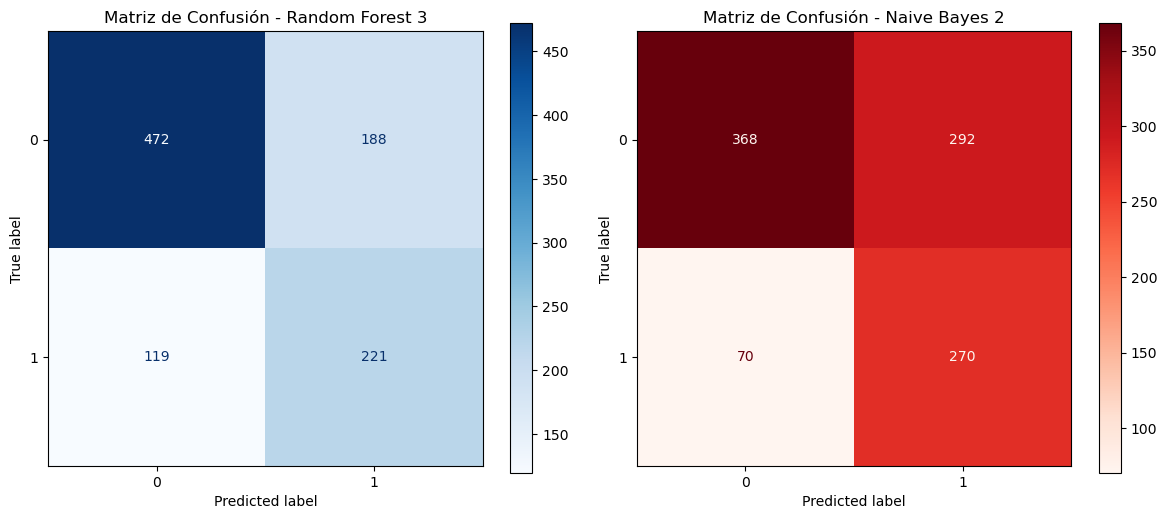

In [51]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

#Reportes
print("="*30)
print("REPORTES DE CLASIFICACIÓN")
print("="*30)
print("\nRandomForest_3:")
print(classification_report(y_test, y_pred))

print("-" * 30)

print("\nNaiveBayes_2 (Umbral personalizado):")
print(classification_report(y_test, y_pred_custom))


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Matriz 1: Random Forest (en el eje 0)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', ax=ax[0])
ax[0].set_title("Matriz de Confusión - Random Forest 3")

# Matriz 2: Naive Bayes (en el eje 1)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_custom, cmap='Reds', ax=ax[1])
ax[1].set_title("Matriz de Confusión - Naive Bayes 2")

plt.tight_layout()
plt.show()

Modelo,Accuracy,Recall (Sensibilidad),F1-Score,Kappa
RandomForest_3,0.693,0.650,0.590,0.348
NaiveBayes_2,0.638,0.794,0.598,0.303

¿Por qué NaiveBayes_2 sigue siendo "el mejor" para Churn?El Recall es masivo (0.794): En predicción de abandono, el Recall es la métrica reina. NaiveBayes_2 detecta casi al 80% de los clientes que se van a ir. RandomForest_3 se queda en un 65%, lo que significa que dejas escapar a un 15% más de clientes que NB sí ve.  El F1-Score te da la razón: Fíjate que el F1-Score de NaiveBayes_2 (0.598) es ligeramente superior al de RandomForest_3 (0.590). Esto indica que, en el balance general entre precisión y sensibilidad, el ajuste que hiciste en Naive Bayes funciona mejor para este conjunto de datos.  El sacrificio del Accuracy: Es cierto que RandomForest_3 tiene un Accuracy más alto (0.693 vs 0.638), pero en problemas de Churn, el Accuracy suele ser una métrica engañosa. Si el modelo predice bien a los que se quedan pero mal a los que se van, el Accuracy será alto, pero el modelo no servirá para el negocio.  El punto a favor de RandomForest_3Donde el Random Forest gana es en el Kappa (0.348). Esto significa que sus predicciones son un poco más "sólidas" o menos aleatorias que las de Naive Bayes (0.303). También tiene una mejor Precisión (0.540 vs 0.480), lo que significa que tiene menos falsas alarmas.  

Conclusión para tu TP
Si yo fuera tú, presentaría a NaiveBayes_2 como el modelo seleccionado.

Justificación técnica para el profe:

"Aunque RandomForest_3 presenta una mejor precisión y un índice Kappa superior, para el caso de negocio de AndesLink priorizamos el Recall (0.794) del modelo NaiveBayes_2. Esto nos permite capturar a la gran mayoría de clientes en riesgo de Churn, asumiendo un costo menor por falsos positivos en favor de una retención más efectiva".

In [ ]:
import joblib
from sklearn.naive_bayes import GaussianNB


model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

# Definimos el nombre del archivo
archivo_final = 'modelo_churn_nb2_andeslink.pkl'

# Guardamos el modelo
joblib.dump(model_nb, archivo_final)

print(f"Tu modelo Naive Bayes 2 ha sido guardado como: {archivo_final}")